In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
def compute_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors

def compute_indep_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    print(IGs_vs_alpha.shape)
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs_vs_alpha[:,np.arange(n_eps),alphas_max]

def compute_t_stat(values, errors):
    t = +values
    mask = errors != 0
    t[mask] /= errors[mask]
    return t

In [3]:
t_19 = 3.579 # threshold of one-tailed t statistics for 19 dof and p=0.001

### Lorenz 96

In [5]:
epsilons = np.linspace(0.,1.5,31)
Ls = np.linspace(100,50000,50,dtype=int) # for CCM
alphas = np.linspace(0.,1.5,50) # for IG
alphas_more = np.linspace(0.,1.5,300)
nseeds = 20
k_te = 3 # for transfer entropy
minzero = False # for transfer entropy

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas_more)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas_more))) 
for iseed, seed in enumerate(range(1, nseeds+1)):
    info_imbalances_X_to_Y_emb[iseed], info_imbalances_Y_to_X_emb[iseed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz96/seed{seed}_morealphas.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(epsilons)))
egc_index_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/lorenz96/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(epsilons),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(epsilons),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles/lorenz96/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(epsilons)))
L_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles/lorenz96/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# transfer entropy, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(
        open(f"../../transfer_entropy/embeddings/pickles/lorenz96/seed{seed}_k{k_te}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

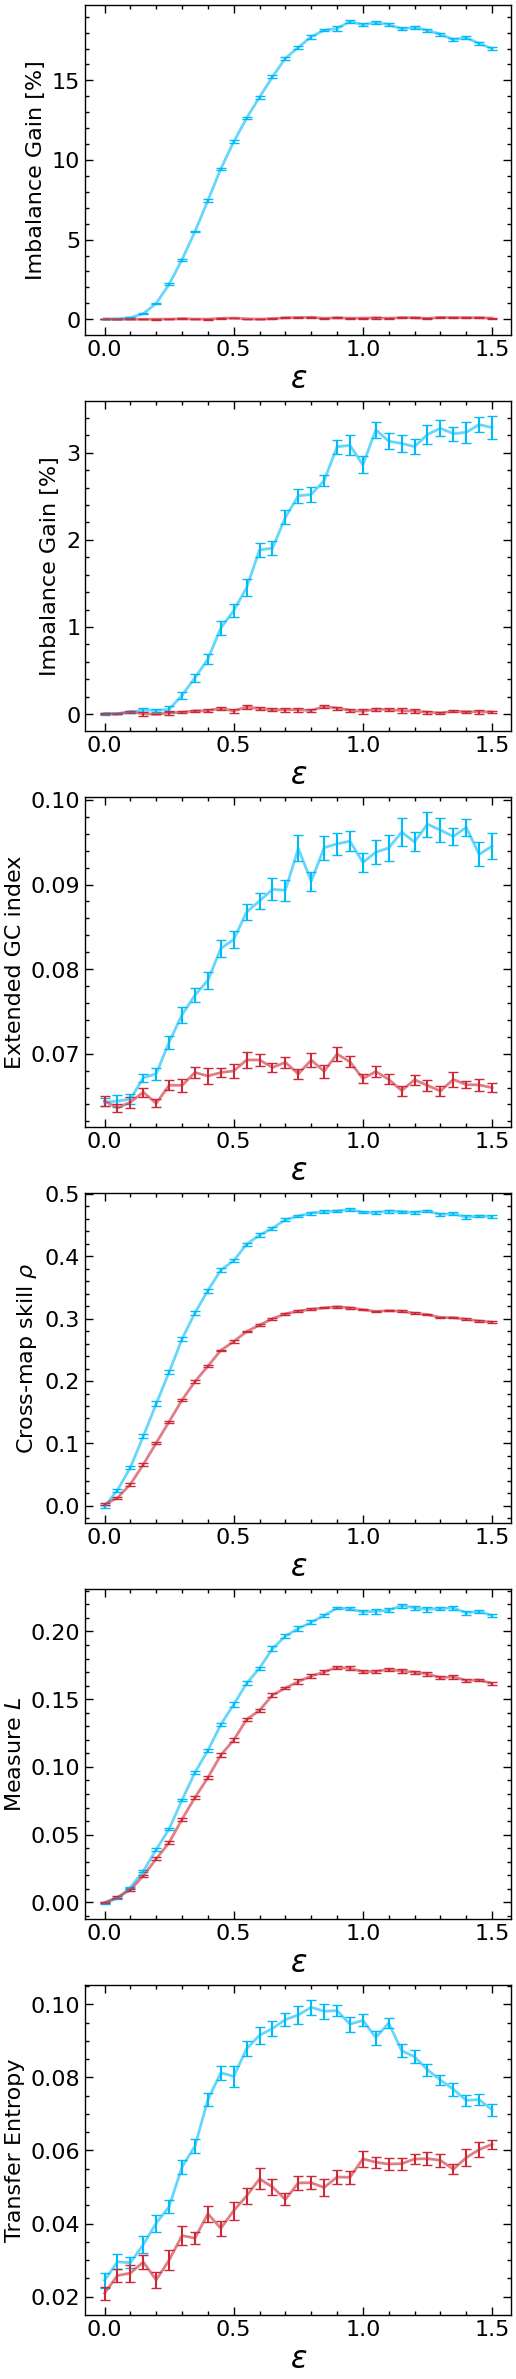

In [10]:
alpha=0.6
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(6,1,figsize=(5.5,30))

ax[0].errorbar(epsilons, IGs_X_to_Y, IGs_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1, label="$X\\rightarrow Y$")
ax[0].errorbar(epsilons, IGs_Y_to_X, IGs_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1, label="$Y\\rightarrow X$")
ax[0].plot(epsilons, IGs_X_to_Y, '-', color=colors[0], alpha=alpha)
ax[0].plot(epsilons, IGs_Y_to_X, '-', color=colors[1], alpha=alpha)
ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].set_xlabel("$\\varepsilon$", fontsize=22)

ax[1].errorbar(epsilons, IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_X_to_Y_emb, '-', color=colors[0], alpha=alpha)
ax[1].plot(epsilons, IGs_Y_to_X_emb, '-', color=colors[1], alpha=alpha)
ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].set_xlabel("$\\varepsilon$", fontsize=22)

ax[2].errorbar(epsilons, egc_index_X_to_Y_avg, egc_index_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].errorbar(epsilons, egc_index_Y_to_X_avg, egc_index_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].plot(epsilons, egc_index_X_to_Y_avg, '-', color=colors[0], alpha=alpha)
ax[2].plot(epsilons, egc_index_Y_to_X_avg, '-', color=colors[1], alpha=alpha)
ax[2].set(ylabel="Extended GC index")
ax[2].set_xlabel("$\\varepsilon$", fontsize=22)

ax[3].errorbar(epsilons, ccm_X_to_Y_avg, ccm_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].errorbar(epsilons, ccm_Y_to_X_avg, ccm_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].plot(epsilons, ccm_X_to_Y_avg, '-', color=colors[0], alpha=alpha)
ax[3].plot(epsilons, ccm_Y_to_X_avg, '-', color=colors[1], alpha=alpha)
ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].set_xlabel("$\\varepsilon$", fontsize=22)

ax[4].errorbar(epsilons, L_X_to_Y_avg, L_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].errorbar(epsilons, L_Y_to_X_avg, L_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].plot(epsilons, L_X_to_Y_avg, '-', color=colors[0], alpha=alpha)
ax[4].plot(epsilons, L_Y_to_X_avg, '-', color=colors[1], alpha=alpha)
ax[4].set(ylabel="Measure $L$")
ax[4].set_xlabel("$\\varepsilon$", fontsize=22)

ax[5].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=alpha)
ax[5].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=alpha)
ax[5].set(ylabel="Transfer Entropy", xlabel="$\\varepsilon$")
ax[5].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig("./figures/lorenz96_for_SIAM.pdf", dpi=300, bbox_inches='tight')
plt.show()